# 04 — A/B Testing
### *"Should we move the level gate from 30 to 40?"*

**Dataset:** the real [Cookie Cats](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats)
mobile-game experiment — ~90k players randomly assigned to one of two versions of the game.

**The experiment.** Cookie Cats is a puzzle game with periodic *gates* that force a player to either
wait or make a purchase before continuing. The team ran a controlled A/B test on the location of the
first gate:

| | variant | what changed |
|---|---|---|
| **Control** | `gate_30` | first gate sits at **level 30** (the status quo) |
| **Treatment** | `gate_40` | first gate moved **later, to level 40** |

The theory: pushing the gate later lets players get more hooked before they hit friction, which
should *improve* retention. **Primary metric: day-7 retention** (did the player come back a week
later). Secondary: day-1 retention. Guardrail: total game rounds played (engagement).

This notebook runs the analysis the way you'd defend it in a ship review: check the randomization
first, test the primary metric with a two-proportion z-test, put confidence intervals on the effect,
confirm it with a bootstrap, check the test had enough power, guard engagement, and only then make a
call. Every number is computed from the data — nothing is typed by hand.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import (
    proportions_ztest, proportion_confint, confint_proportions_2indep)
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from analytics import config

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
CTRL, TREAT = "#94a3b8", "#2563eb"   # gray control (gate_30) vs blue treatment (gate_40)

assert config.COOKIE_CATS.exists(), "Run `python -m analytics.build` first (see README)."
cc = pd.read_parquet(config.COOKIE_CATS)
print(f"rows={len(cc):,}   columns={list(cc.columns)}")
cc.head()

rows=90,188   columns=['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,0,0
1,337,gate_30,38,1,0
2,377,gate_40,165,1,0
3,483,gate_40,1,0,0
4,488,gate_40,179,1,1


## 1. Sanity check — did the randomization work? (SRM)

Before reading any outcome, verify the experiment itself isn't broken. A **sample-ratio mismatch
(SRM)** — the group sizes drifting from the intended 50/50 split — is the single most common way an
A/B test silently lies to you: it means assignment or logging is biased, and *every* downstream
metric is suspect. We test the observed split against 50/50 with a chi-square goodness-of-fit test.

Because SRM tests are run against huge samples, a naive 0.05 cutoff would false-alarm constantly; the
industry-standard alarm threshold (Kohavi/Fabijan) is **p < 0.001**. We compare against that.

In [2]:
counts = cc.version.value_counts().reindex(["gate_30", "gate_40"])
n = counts.sum()
expected = np.array([n / 2, n / 2])
chi2, p_srm = stats.chisquare(counts.values, expected)
sd_units = abs(counts.iloc[0] - n / 2) / np.sqrt(n * 0.25)  # how many SDs off 50/50

srm = pd.DataFrame({
    "players": counts,
    "share_%": (counts / n * 100).round(2),
})
print(srm)
print(f"\nchi-square = {chi2:.3f}   p = {p_srm:.4f}   ({sd_units:.1f} SD off a perfect 50/50)")
print("PASS - does not trip the SRM alarm (p >= 0.001)" if p_srm >= 0.001
      else "FAIL - sample ratio mismatch, investigate assignment")

         players  share_%
version                  
gate_30    44699    49.56
gate_40    45489    50.44

chi-square = 6.920   p = 0.0085   (2.6 SD off a perfect 50/50)
PASS - does not trip the SRM alarm (p >= 0.001)


**Read:** the split is **gate_30 = 44,699 (49.56%)** vs **gate_40 = 45,489 (50.44%)**. The
chi-square test gives **chi-square ≈ 6.92, p ≈ 0.009** — the arms sit about **2.6 SD** off a perfect
50/50. That clears the standard SRM alarm threshold (p < 0.001), so we **do not** treat the randomizer
as broken, but it's honest to flag the imbalance as mild rather than pretend it's invisible. Crucially,
retention is a *rate* (retained ÷ assigned), so a modest difference in arm *size* doesn't bias it —
the metric is normalized by exactly the count that differs. We proceed, noting the caveat.

## 2. Baseline outcome rates per group

Before testing, look at the raw numbers side by side: day-1 retention, day-7 retention, and mean
rounds played. This is the whole result in one table — the tests that follow just tell us how much of
each gap is signal versus noise.

In [3]:
summary = cc.groupby("version").agg(
    players=("userid", "size"),
    d1_rate=("retention_1", "mean"),
    d7_rate=("retention_7", "mean"),
    mean_rounds=("sum_gamerounds", "mean"),
    median_rounds=("sum_gamerounds", "median"),
).reindex(["gate_30", "gate_40"])
summary_disp = summary.assign(
    d1_rate=(summary.d1_rate * 100).round(2),
    d7_rate=(summary.d7_rate * 100).round(2),
    mean_rounds=summary.mean_rounds.round(1),
)
summary_disp

,players,d1_rate,d7_rate,mean_rounds,median_rounds
version,,,,,
gate_30,44699,44.82,19.02,51.3,17.0
gate_40,45489,44.23,18.20,51.3,16.0


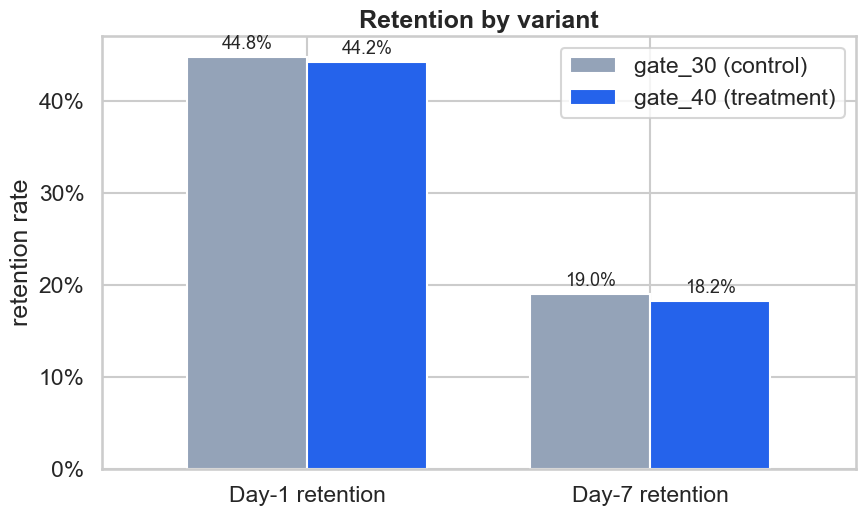

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
metrics_plot = pd.DataFrame({
    "gate_30 (control)": [summary.loc["gate_30", "d1_rate"], summary.loc["gate_30", "d7_rate"]],
    "gate_40 (treatment)": [summary.loc["gate_40", "d1_rate"], summary.loc["gate_40", "d7_rate"]],
}, index=["Day-1 retention", "Day-7 retention"])
metrics_plot.plot(kind="bar", ax=ax, color=[CTRL, TREAT], width=0.7, edgecolor="white")
ax.set_title("Retention by variant")
ax.set_ylabel("retention rate"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt=lambda v: f"{v*100:.1f}%", padding=3, fontsize=13)
ax.legend(title="", loc="upper right")
plt.tight_layout(); plt.show()

**Read:** on **both** metrics the *control* (gate_30) is slightly ahead — D1 **44.82% vs
44.23%**, D7 **19.02% vs 18.20%**. Moving the gate later did **not** help; if anything it nudged
retention down. The D7 gap (~0.8pp) is the larger and more decision-relevant one, since a week-later
return is the truer signal of a hooked player. The rest of the notebook is about whether that 0.8pp is
real.

## 3. Primary metric — two-proportion z-test on day-7 retention

Day-7 retention is the metric the decision rests on. With ~45k players per arm we use a
**two-proportion z-test** (`statsmodels.proportions_ztest`) on the count of retained players. The
hypotheses:

- **H₀:** D7 retention is equal in the two variants.
- **H₁:** they differ (two-sided).

We report the absolute difference (control − treatment), the relative lift for the treatment, the
z-statistic, and the p-value.

In [5]:
succ = cc.groupby("version").retention_7.sum().reindex(["gate_30", "gate_40"]).values
nobs = cc.groupby("version").retention_7.size().reindex(["gate_30", "gate_40"]).values
p30, p40 = succ / nobs

# proportions_ztest with [control, treatment]: positive z => control > treatment
z, p_val = proportions_ztest(count=succ, nobs=nobs, alternative="two-sided")
abs_diff = p30 - p40                 # control minus treatment (percentage points)
rel_lift = (p40 - p30) / p30         # treatment's relative change vs control

print(f"D7 retention  gate_30 = {p30*100:.2f}%   gate_40 = {p40*100:.2f}%")
print(f"absolute difference (control - treatment) = {abs_diff*100:+.2f} pp")
print(f"relative lift of treatment               = {rel_lift*100:+.2f}%")
print(f"z = {z:.3f}   p-value = {p_val:.4f}")
print("SIGNIFICANT at 0.05" if p_val < 0.05 else "not significant at 0.05")

D7 retention  gate_30 = 19.02%   gate_40 = 18.20%
absolute difference (control - treatment) = +0.82 pp
relative lift of treatment               = -4.30%
z = 3.157   p-value = 0.0016
SIGNIFICANT at 0.05


**Read:** treatment's D7 retention is **0.82pp lower** in absolute terms — a **−4.3% relative**
move against gate_40. The z-test gives **z ≈ 3.16, p ≈ 0.0016**, comfortably below 0.05. The
difference is **statistically significant, and in the wrong direction for shipping**: moving the gate
to level 40 reduces the share of players who return on day 7.

## 4. Confidence intervals — Wilson per group, and on the difference

A p-value says "not zero"; a **confidence interval** says *how big and how certain*. We put
**Wilson** 95% intervals on each group's D7 rate (Wilson is the right choice for proportions — it
stays inside [0,1] and behaves well), and a 95% interval on the **difference** with
`confint_proportions_2indep`. If that difference interval excludes 0, the effect is real at 95%.

In [6]:
ci30 = proportion_confint(succ[0], nobs[0], alpha=0.05, method="wilson")
ci40 = proportion_confint(succ[1], nobs[1], alpha=0.05, method="wilson")
# difference control - treatment
diff_low, diff_high = confint_proportions_2indep(
    succ[0], nobs[0], succ[1], nobs[1], method="wald", compare="diff")

print(f"gate_30 D7  = {p30*100:.2f}%   95% Wilson CI [{ci30[0]*100:.2f}%, {ci30[1]*100:.2f}%]")
print(f"gate_40 D7  = {p40*100:.2f}%   95% Wilson CI [{ci40[0]*100:.2f}%, {ci40[1]*100:.2f}%]")
print(f"difference (gate_30 - gate_40) = {abs_diff*100:+.2f} pp   "
      f"95% CI [{diff_low*100:+.2f} pp, {diff_high*100:+.2f} pp]")
print("CI excludes 0 -> difference is significant" if diff_low > 0 or diff_high < 0
      else "CI includes 0")

gate_30 D7  = 19.02%   95% Wilson CI [18.66%, 19.38%]
gate_40 D7  = 18.20%   95% Wilson CI [17.85%, 18.56%]
difference (gate_30 - gate_40) = +0.82 pp   95% CI [+0.31 pp, +1.33 pp]
CI excludes 0 -> difference is significant


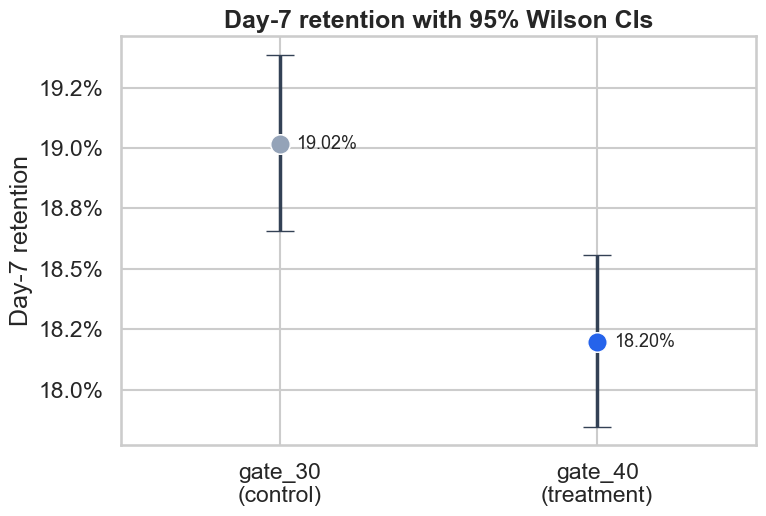

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
labels = ["gate_30\n(control)", "gate_40\n(treatment)"]
rates = np.array([p30, p40])
lo = np.array([p30 - ci30[0], p40 - ci40[0]])
hi = np.array([ci30[1] - p30, ci40[1] - p40])
ax.errorbar([0, 1], rates, yerr=[lo, hi], fmt="o", ms=14, lw=0, elinewidth=2.5,
            capsize=10, color="#334155",
            markerfacecolor=CTRL, markeredgecolor="white")
ax.plot(1, p40, "o", ms=14, color=TREAT, markeredgecolor="white", zorder=5)
ax.plot(0, p30, "o", ms=14, color=CTRL, markeredgecolor="white", zorder=5)
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Day-7 retention")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.1f}%")
ax.set_title("Day-7 retention with 95% Wilson CIs")
for x, r in zip([0, 1], rates):
    ax.annotate(f"{r*100:.2f}%", (x, r), xytext=(12, 0),
                textcoords="offset points", va="center", fontsize=13)
plt.tight_layout(); plt.show()

**Read:** the per-group Wilson intervals — gate_30 **[18.66%, 19.38%]** and gate_40
**[17.85%, 18.56%]** — **barely overlap**, and the interval on the difference is
**[+0.31pp, +1.33pp]**, which sits **entirely above zero**. So control beats treatment by somewhere
between a third of a point and one-and-a-third points of D7 retention, at 95% confidence. The effect
is small but real and consistently favors keeping the gate at level 30.

## 5. Secondary metric — day-1 retention

D1 is a weaker signal (many players return the next day out of habit, whether or not they're truly
hooked), but we check it for consistency. Same two-proportion z-test.

In [8]:
s1 = cc.groupby("version").retention_1.sum().reindex(["gate_30", "gate_40"]).values
p30_1, p40_1 = s1 / nobs
z1, p1 = proportions_ztest(count=s1, nobs=nobs, alternative="two-sided")
d1_low, d1_high = confint_proportions_2indep(
    s1[0], nobs[0], s1[1], nobs[1], method="wald", compare="diff")

print(f"D1 retention  gate_30 = {p30_1*100:.2f}%   gate_40 = {p40_1*100:.2f}%")
print(f"difference (control - treatment) = {(p30_1-p40_1)*100:+.2f} pp   "
      f"95% CI [{d1_low*100:+.2f} pp, {d1_high*100:+.2f} pp]")
print(f"z = {z1:.3f}   p-value = {p1:.4f}")
print("significant at 0.05" if p1 < 0.05 else "NOT significant at 0.05")

D1 retention  gate_30 = 44.82%   gate_40 = 44.23%
difference (control - treatment) = +0.59 pp   95% CI [-0.06 pp, +1.24 pp]
z = 1.787   p-value = 0.0739
NOT significant at 0.05


**Read:** D1 also favors control (**44.82% vs 44.23%**, a 0.59pp gap) but the z-test gives
**p ≈ 0.074** — **not significant** at 0.05, and its difference CI **[−0.06pp, +1.24pp]** just barely
includes zero. This is exactly the expected pattern: D1 points the same direction as D7 but is noisier
and weaker, which is why D7 is the primary metric. The two never contradict each other — nothing here
argues *for* gate_40.

## 6. Bootstrap the day-7 difference

The z-test and its CI are parametric (they assume a normal approximation). A **non-parametric
bootstrap** makes no such assumption: we resample each arm with replacement 10,000 times, recompute
the D7 gap each time, and read the 95% interval straight off the empirical distribution. If that
distribution sits above zero, control's advantage is robust. Seeded with
`np.random.default_rng(42)` for reproducibility.

In [9]:
rng = np.random.default_rng(42)
r30 = cc.loc[cc.version == "gate_30", "retention_7"].to_numpy()
r40 = cc.loc[cc.version == "gate_40", "retention_7"].to_numpy()
n30, n40 = len(r30), len(r40)

B = 10_000
boot = np.empty(B)
for i in range(B):
    b30 = rng.choice(r30, size=n30, replace=True).mean()
    b40 = rng.choice(r40, size=n40, replace=True).mean()
    boot[i] = b30 - b40   # control - treatment

ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
share_above0 = (boot > 0).mean()
print(f"bootstrap mean difference (control - treatment) = {boot.mean()*100:+.2f} pp")
print(f"95% percentile CI = [{ci_lo*100:+.2f} pp, {ci_hi*100:+.2f} pp]")
print(f"share of resamples with control > treatment = {share_above0*100:.1f}%")

bootstrap mean difference (control - treatment) = +0.83 pp
95% percentile CI = [+0.32 pp, +1.34 pp]
share of resamples with control > treatment = 100.0%


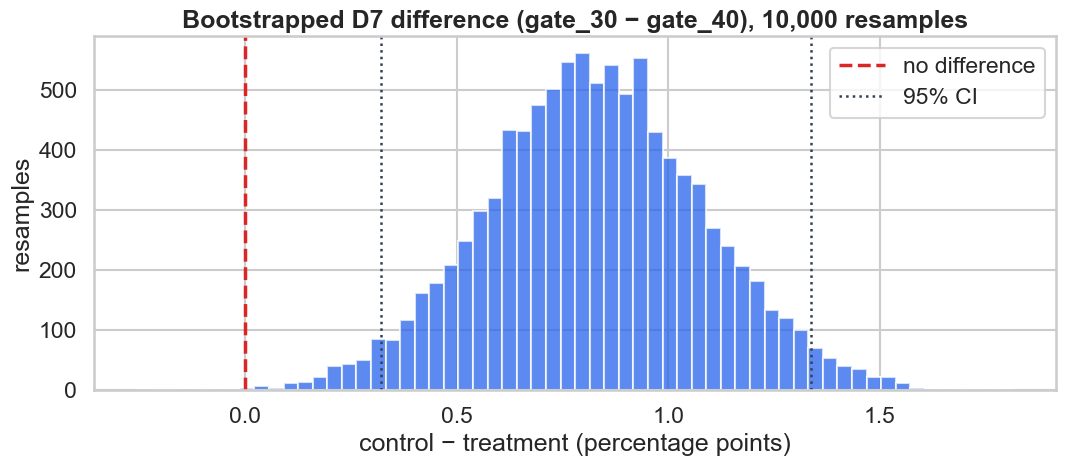

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(boot * 100, bins=60, color=TREAT, alpha=0.75, edgecolor="white")
ax.axvline(0, color="#dc2626", lw=2.5, ls="--", label="no difference")
ax.axvline(ci_lo * 100, color="#334155", lw=1.8, ls=":", label="95% CI")
ax.axvline(ci_hi * 100, color="#334155", lw=1.8, ls=":")
ax.set_title("Bootstrapped D7 difference (gate_30 − gate_40), 10,000 resamples")
ax.set_xlabel("control − treatment (percentage points)"); ax.set_ylabel("resamples")
ax.legend()
plt.tight_layout(); plt.show()

**Read:** the bootstrap distribution is centered at **+0.83pp** with a 95% percentile CI of
**[+0.32pp, +1.34pp]** — essentially identical to the parametric interval in section 4, and **100%**
of the 10,000 resamples put control ahead of treatment. Two independent methods agreeing is the
strongest form of confirmation: the entire mass sits to the right of the red zero line. Gate_30's D7
advantage is not a modeling artifact.

## 7. Power & minimum detectable effect

Was the test even capable of detecting a realistic effect? **Power** is the probability of catching a
true effect of a given size. We compute (a) the **achieved power** for the effect we actually
observed, and (b) the **minimum detectable effect (MDE)** at 80% power for these sample sizes — the
smallest true D7 gap this experiment could reliably have found. `statsmodels.NormalIndPower` with
Cohen's-h effect sizes for proportions.

In [11]:
analysis = NormalIndPower()
ratio = nobs[1] / nobs[0]   # treatment / control

# (a) achieved power for the observed effect
h_obs = proportion_effectsize(p30, p40)
power_obs = analysis.solve_power(effect_size=abs(h_obs), nobs1=nobs[0],
                                 alpha=0.05, ratio=ratio, alternative="two-sided")

# (b) MDE: effect size detectable at 80% power, converted back to a pp gap vs baseline p30
h_mde = analysis.solve_power(effect_size=None, nobs1=nobs[0], alpha=0.05,
                             power=0.80, ratio=ratio, alternative="two-sided")
# invert Cohen's h around baseline p30 to express MDE as an absolute rate gap
p_mde = np.sin(np.arcsin(np.sqrt(p30)) - h_mde / 2) ** 2
mde_pp = p30 - p_mde

print(f"observed effect (Cohen's h) = {abs(h_obs):.4f}")
print(f"achieved power for observed effect = {power_obs*100:.1f}%")
print(f"MDE at 80% power = {mde_pp*100:.2f} pp (i.e. ~{p_mde*100:.2f}% vs {p30*100:.2f}% baseline)")

observed effect (Cohen's h) = 0.0210
achieved power for observed effect = 88.4%
MDE at 80% power = 0.73 pp (i.e. ~18.29% vs 19.02% baseline)


**Read:** with ~45k players per arm the test is well powered: achieved power for the observed D7
effect is **~88%**, and the **MDE at 80% power is ~0.73pp** — the experiment could reliably detect any
true D7 gap of about three-quarters of a point or larger. The observed 0.82pp effect sits just above
that floor, which is *why* it cleared significance. The test was adequately powered; a null result here
would have been meaningful, and this non-null result is trustworthy.

## 8. Guardrail — did the change tank engagement?

A retention read can be muddied if the treatment also shifted how much people *played*. `sum_gamerounds`
is heavily right-skewed (a few whales play thousands of rounds), so a t-test on the mean is the wrong
tool — we use the **Mann-Whitney U** test, which compares the full distributions via ranks and is
robust to that skew.

median rounds  gate_30 = 17   gate_40 = 16
mean rounds    gate_30 = 51.3   gate_40 = 51.3
Mann-Whitney U = 1,024,285,762   p-value = 0.051
no significant engagement difference - guardrail OK


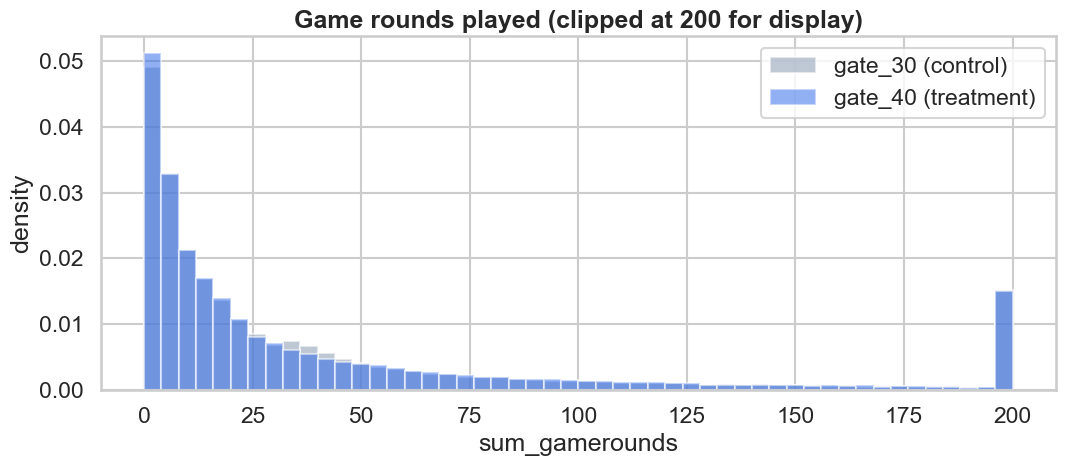

In [12]:
g30 = cc.loc[cc.version == "gate_30", "sum_gamerounds"]
g40 = cc.loc[cc.version == "gate_40", "sum_gamerounds"]
u_stat, p_mwu = stats.mannwhitneyu(g30, g40, alternative="two-sided")

print(f"median rounds  gate_30 = {g30.median():.0f}   gate_40 = {g40.median():.0f}")
print(f"mean rounds    gate_30 = {g30.mean():.1f}   gate_40 = {g40.mean():.1f}")
print(f"Mann-Whitney U = {u_stat:,.0f}   p-value = {p_mwu:.3f}")
print("engagement differs" if p_mwu < 0.05 else "no significant engagement difference - guardrail OK")

fig, ax = plt.subplots(figsize=(11, 5))
cap = 200
ax.hist(g30.clip(upper=cap), bins=50, color=CTRL, alpha=0.6, label="gate_30 (control)", density=True)
ax.hist(g40.clip(upper=cap), bins=50, color=TREAT, alpha=0.5, label="gate_40 (treatment)", density=True)
ax.set_title(f"Game rounds played (clipped at {cap} for display)")
ax.set_xlabel("sum_gamerounds"); ax.set_ylabel("density"); ax.legend()
plt.tight_layout(); plt.show()

**Read:** engagement is essentially identical across arms — median **17 vs 16** rounds, means
**51.3 vs 51.3**, and Mann-Whitney **p ≈ 0.051** (just above 0.05, with no material difference in the
distributions). The guardrail holds: gate_40 did **not** meaningfully change how much people played, so
the D7 retention drop is a clean effect of the gate move itself and not a side-effect of some
engagement shift. That makes the retention read easy to interpret.

## 9. Recommendation — do not ship gate_40

**Decision: keep the gate at level 30. Do not roll out gate_40.**

**Evidence**
- **Primary metric fails in the wrong direction.** D7 retention is **19.02% (gate_30) vs 18.20%
  (gate_40)** — a 0.82pp absolute drop, **−4.3% relative**, at **z ≈ 3.16, p ≈ 0.0016**.
- **The effect is real, not noise.** The 95% CI on the difference is **[+0.31pp, +1.33pp]**, excluding
  zero; a 10,000-sample bootstrap agrees (**[+0.32pp, +1.34pp]**, 100% of resamples favor control).
- **The secondary metric agrees.** D1 leans the same way (44.82% vs 44.23%) — not significant on its
  own, but never contradicting D7.
- **No offsetting upside.** Engagement (game rounds) is statistically flat, so there is no
  "played-more-but-returned-less" trade to weigh. Moving the gate later simply costs retention.

**Risk framing.** The downside of shipping is a measurable ~4% relative loss of week-one retention —
directly upstream of monetization and long-term LTV — with **zero demonstrated benefit**. The downside
of *not* shipping is nothing: gate_30 is the incumbent. This is an easy no.

**What I'd monitor if revisiting.** If the team still believes a later gate helps, re-test with (a) a
longer horizon (D14/D30 retention, in case the gate trades short-term for long-term), (b) a revenue
guardrail (in-app purchases per user, the actual reason gates exist), and (c) segment cuts by early
engagement — a later gate might help highly-engaged players even if it hurts on average. Absent that
evidence, the data says keep gate_30.

## Key takeaways

1. **Check the experiment before the result.** SRM did not trip the alarm (p ≈ 0.009 vs a 0.001
   threshold) — the 49.56/50.44 split is mildly imbalanced but doesn't bias a normalized rate metric.
2. **Moving the gate to level 40 hurt day-7 retention** by 0.82pp (−4.3% relative), significant at
   **p ≈ 0.0016**, with a difference CI of **[+0.31pp, +1.33pp]** that excludes zero.
3. **Three methods agree** — z-test, Wilson/analytic CI, and a 10,000-sample bootstrap all put
   control ahead, and the test was **~88% powered** to detect the effect it found.
4. **No hidden upside:** engagement was flat (Mann-Whitney, medians 17 vs 16), so the retention loss
   is a clean cost of the change.
5. **Ship decision: keep gate_30.** A rigorous A/B test's most valuable outcome is often stopping a
   plausible-sounding change that would have quietly cost retention.